In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings

warnings.filterwarnings('ignore')

!pip install openpyxl
path = '/content/Integrating AI-DataSet_Youth_Wellness.xlsx'
df = pd.read_excel(path, sheet_name="Sheet3")

In [ ]:
df.shape
df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


In [ ]:
df.describe()

,is_depression
count,7731.000000
mean,0.495537
std,0.500012
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
X = df['clean_text']
y = df['is_depression']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((6184,), (1547,))

In [ ]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

Training Accuracy: 0.9632923673997412
DT Accuracy(For Entropy): 0.9172592113768584

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       783
           1       0.95      0.88      0.91       764

    accuracy                           0.92      1547
   macro avg       0.92      0.92      0.92      1547
weighted avg       0.92      0.92      0.92      1547



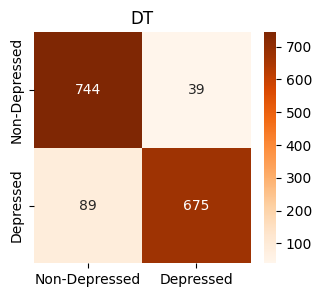

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=10,
    min_samples_leaf=5,
    min_samples_split=5,
    class_weight= 'balanced',
    random_state=42
  )

clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)

y_train_pred = clf_entropy.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

print("DT Accuracy(For Entropy):", accuracy_score(y_test, y_pred_entropy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropy))

cm_entropy = confusion_matrix(y_test, y_pred_entropy)
plt.figure(figsize=(3.5,3))
sns.heatmap(cm_entropy, annot=True, fmt="d", cmap="Oranges", xticklabels=["Non-Depressed", "Depressed"], yticklabels=["Non-Depressed", "Depressed"])
plt.title("DT")
plt.show()

Training Accuracy: 0.9595730918499353
DT Accuracy(For gini): 0.9146735617323852

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       783
           1       0.94      0.88      0.91       764

    accuracy                           0.91      1547
   macro avg       0.92      0.91      0.91      1547
weighted avg       0.92      0.91      0.91      1547



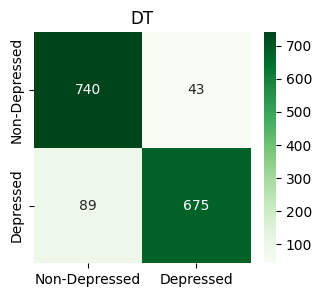

In [ ]:
clf_gini = DecisionTreeClassifier(criterion="gini", max_depth= 10, min_samples_leaf = 5, min_samples_split=5,
    class_weight= 'balanced', random_state=42)

clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)

y_train_pred = clf_gini.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

print("DT Accuracy(For gini):", accuracy_score(y_test, y_pred_gini))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gini))

cm_gini = confusion_matrix(y_test, y_pred_gini)
plt.figure(figsize=(3.5,3))
sns.heatmap(cm_gini, annot=True, fmt="d", cmap="Greens", xticklabels=["Non-Depressed", "Depressed"], yticklabels=["Non-Depressed", "Depressed"])
plt.title("DT")
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.8 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.svm import LinearSVC

X_text = df['clean_text'].astype(str).values
y = df['is_depression'].values


X_train_text, X_test_text, y_train, y_test, train_idx, test_idx = train_test_split(
    X_text,
    y,
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_tr_text, X_val_text, y_tr, y_val = train_test_split(
    X_train_text, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
from sklearn.metrics import accuracy_score

def objective(trial):

    max_features = trial.suggest_int("max_features", 2000, 7740, step=1000)
    ngram_range = trial.suggest_categorical("ngram_range", [(1, 1), (1, 2)])


    C = trial.suggest_float("C", 1e-3, 1e2, log=True)
    class_weight_choice = trial.suggest_categorical(
        "class_weight", ["none", "balanced"]
    )
    class_weight = None if class_weight_choice == "none" else "balanced"


    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range
    )

    X_tr_vec = vectorizer.fit_transform(X_tr_text)
    X_val_vec = vectorizer.transform(X_val_text)
    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        random_state=42,
        max_iter=250
    )

    model.fit(X_tr_vec, y_tr)

    y_val_pred = model.predict(X_val_vec)
    val_acc = accuracy_score(y_val, y_val_pred)

    return val_acc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best validation accuracy:", study.best_value)
print("Best params:", study.best_params)
print("Best validation accuracy:", study.best_value)


[I 2026-02-07 09:41:26,674] A new study created in memory with name: no-name-27533e05-cfd4-4b26-8236-63fc379ca4e6


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-02-07 09:41:32,763] Trial 0 finished with value: 0.9482619240097009 and parameters: {'max_features': 4000, 'ngram_range': (1, 2), 'C': 9.776619278340904, 'class_weight': 'none'}. Best is trial 0 with value: 0.9482619240097009.
[I 2026-02-07 09:41:34,612] Trial 1 finished with value: 0.9587712206952304 and parameters: {'max_features': 2000, 'ngram_range': (1, 1), 'C': 0.4339285067047445, 'class_weight': 'none'}. Best is trial 1 with value: 0.9587712206952304.
[I 2026-02-07 09:41:36,487] Trial 2 finished with value: 0.9620048504446241 and parameters: {'max_features': 6000, 'ngram_range': (1, 1), 'C': 0.26084139614464186, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9620048504446241.
[I 2026-02-07 09:41:42,473] Trial 3 finished with value: 0.9628132578819725 and parameters: {'max_features': 7000, 'ngram_range': (1, 2), 'C': 0.8532291522733638, 'class_weight': 'none'}. Best is trial 3 with value: 0.9628132578819725.
[I 2026-02-07 09:41:43,690] Trial 4 finished with va

In [ ]:
best_params = study.best_params
best_C = best_params["C"]
best_class_weight = None if best_params["class_weight"] == "none" else "balanced"
best_max_features = best_params["max_features"]
best_ngram_range = best_params["ngram_range"]


final_vectorizer = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram_range
)

X_train_vec = final_vectorizer.fit_transform(X_train_text)
X_test_vec = final_vectorizer.transform(X_test_text)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

final_model = LinearSVC(
    C=best_C,
    class_weight=best_class_weight,
    random_state=42,
    max_iter=10000
)
final_model.fit(X_train_vec, y_train)
y_test_pred = final_model.predict(X_test_vec)

test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

Training Accuracy: 0.9975743855109961

Test Accuracy: 0.9651

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       780
           1       0.98      0.95      0.96       767

    accuracy                           0.97      1547
   macro avg       0.97      0.96      0.97      1547
weighted avg       0.97      0.97      0.97      1547

Approximate geometric margin: 0.041661


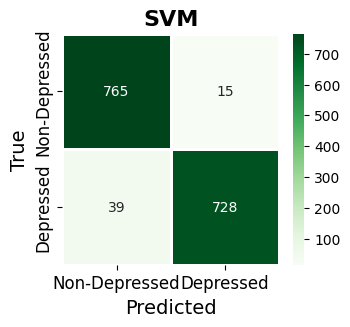

In [ ]:
from sklearn.metrics import classification_report

print("Training Accuracy:", accuracy_score(y_train, final_model.predict(X_train_vec)))
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred))

w = final_model.coef_
w_norm = np.linalg.norm(w)
margin = 1.0 / w_norm
print(f"Approximate geometric margin: {margin:.6f}")


plt.figure(figsize=(3.5, 3))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='white',
    xticklabels=["Non-Depressed", "Depressed"],
    yticklabels=["Non-Depressed", "Depressed"]
)

plt.title(
    "SVM",
    fontsize=16, weight="bold"
)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
plt.show()

TEXT: woke up and feel like rubbish rest or chill indoors and play xbox with a cold drink
True Label: 0 | Predicted: 1
--------------------------------------------------------------------------------
TEXT: please give me your grounding exercise to keep me busy a i make a long distance move happy thought appreciated
True Label: 1 | Predicted: 0
--------------------------------------------------------------------------------
TEXT: title should ve been will it work within the hour i ll electrocute myself i ll sit with my foot under salt water one end of the electrical wire will be under water and the other plugged in the outlet will it work
True Label: 1 | Predicted: 0
--------------------------------------------------------------------------------
TEXT: this week just seems to get longer and longer in term of how much i need to do and how much i m actually going to get done
True Label: 0 | Predicted: 1
--------------------------------------------------------------------------------
TEXT:

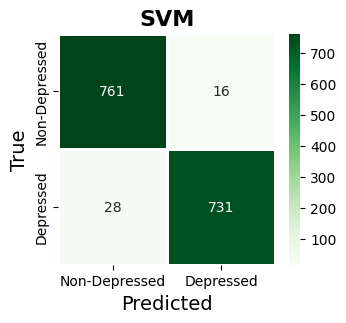

Accuracy on cleaned dataset: 0.9713541666666666


In [ ]:
y_pred = y_test_pred
mis_idx = np.where(y_pred != y_test)[0]

for i in mis_idx[:50]:
    print("TEXT:", X_test_text[i])
    print("True Label:", y_test[i], "| Predicted:", y_pred[i])
    print("-" * 80)


test_idx = np.array(test_idx)
mis_row_ids = test_idx[mis_idx]

#print(f"\nTotal misclassified samples in test set: {len(mis_row_ids)}")


df_cleaned = df.drop(index=mis_row_ids).reset_index(drop=True)

print(f"Original dataset size: {len(df)} rows")
print(f"Cleaned dataset size:  {len(df_cleaned)} rows")

X_text_clean = df_cleaned['clean_text'].astype(str).values
y_clean = df_cleaned['is_depression'].values


X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_text_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


vectorizer_clean = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram_range
)

X_train_vec_clean = vectorizer_clean.fit_transform(X_train_clean)
X_test_vec_clean = vectorizer_clean.transform(X_test_clean)


model_clean = LinearSVC(
    C=best_C,
    class_weight=best_class_weight,
    random_state=42,
    max_iter=10000
)

model_clean.fit(X_train_vec_clean, y_train_clean)
y_pred_clean = model_clean.predict(X_test_vec_clean)


cm_svm = confusion_matrix(y_test_clean, y_pred_clean)

plt.figure(figsize=(3.5, 3))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='white',
    xticklabels=["Non-Depressed", "Depressed"],
    yticklabels=["Non-Depressed", "Depressed"]
)

plt.title("SVM", fontsize=16, weight="bold")
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.show()

print("Accuracy on cleaned dataset:", accuracy_score(y_test_clean, y_pred_clean))

In [ ]:
!pip install -q textstat sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.5 MB/s eta 0:00:00


In [ ]:
import os, re
import nltk
import textstat
import torch
import joblib
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer

CONF = {
    "data_path": "/content/Integrating AI-DataSet_Youth_Wellness.xlsx",
    "save_dir": "processed_data",
    "sbert_model": "all-mpnet-base-v2",
    "tfidf_max_features": 5000,
}

In [ ]:
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)

True

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

class DepressionFeatureStore:

    def __init__(self, config):
        self.config = config

    def load_and_clean(self):

        df = pd.read_excel(self.config["data_path"], sheet_name="Sheet3")
        df["clean_text"] = df["clean_text"].astype(str).fillna("")
        df["clean_text"] = df["clean_text"].apply(lambda x: " ".join(x.split()))
        self.df = df
        return self

    def extract_psycholinguistic(self):
        sid = SentimentIntensityAnalyzer()

        self.df["vader_compound"] = self.df["clean_text"].apply(lambda x: sid.polarity_scores(x)["compound"])
        self.df["vader_neg"] = self.df["clean_text"].apply(lambda x: sid.polarity_scores(x)["neg"])
        self.df["vader_pos"] = self.df["clean_text"].apply(lambda x: sid.polarity_scores(x)["pos"])

        def pronoun_ratio(t):
            w = t.lower().split()
            if not w: return 0
            p = len(re.findall(r"\b(i|me|my|mine|myself)\b", t.lower()))
            return p / len(w)

        self.df["pronoun_ratio"] = self.df["clean_text"].apply(pronoun_ratio)
        self.df["readability"] = self.df["clean_text"].apply(textstat.flesch_reading_ease)
        self.df["word_count"] = self.df["clean_text"].apply(lambda x: len(x.split()))
        return self

    def extract_tfidf(self):
        vec = TfidfVectorizer(
            max_features=self.config["tfidf_max_features"],
            ngram_range=(1, 3),
            stop_words="english",
            sublinear_tf=True
        )

        tfidf = vec.fit_transform(self.df["clean_text"])
        tfidf_cols = [f"tfidf_{v}" for v in vec.get_feature_names_out()]

        self.df = pd.concat(
            [self.df, pd.DataFrame(tfidf.toarray(), columns=tfidf_cols)],
            axis=1
        )

        self.tfidf_vectorizer = vec
        return self

    def extract_sbert(self):
        model = SentenceTransformer(self.config["sbert_model"], device="cuda" if torch.cuda.is_available() else "cpu")
        emb = model.encode(self.df["clean_text"].tolist(), batch_size=32, show_progress_bar=True)

        emb_df = pd.DataFrame(emb, columns=[f"sbert_{i}" for i in range(emb.shape[1])])
        self.df = pd.concat([self.df, emb_df], axis=1)
        return self

    def save(self):
        os.makedirs(self.config["save_dir"], exist_ok=True)
        self.df.to_pickle(f"{self.config['save_dir']}/full_features.pkl")
        joblib.dump(self.tfidf_vectorizer, f"{self.config['save_dir']}/tfidf_vectorizer.joblib")
        print("Phase 0 Done! Feature Store Created.")

In [ ]:
pipeline = DepressionFeatureStore(CONF)
pipeline.load_and_clean().extract_psycholinguistic().extract_tfidf().extract_sbert().save()
df = pd.read_pickle("processed_data/full_features.pkl")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head(3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/242 [00:00<?, ?it/s]

KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       780
           1       1.00      0.96      0.98       767

    accuracy                           0.98      1547
   macro avg       0.98      0.98      0.98      1547
weighted avg       0.98      0.98      0.98      1547



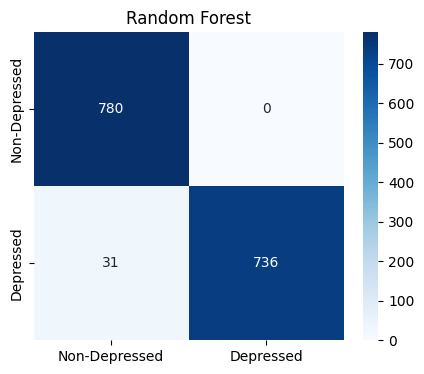

AUC = 0.9998679503894627


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc
)


df = pd.read_pickle("processed_data/full_features.pkl")

drop_cols = [c for c in df.columns if c.startswith("sbert_")] + ["clean_text"]
X = df.drop(columns=drop_cols)
y = df["is_depression"]


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm_rf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Depressed", "Depressed"], yticklabels=["Non-Depressed", "Depressed"])
plt.title("Random Forest")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print("AUC =", auc(fpr, tpr))

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

path = '/content/Integrating AI-DataSet_Youth_Wellness.xlsx'
df = pd.read_excel(path, sheet_name="Sheet3")

possible_text = ["text", "clean_text", "body", "content", "sentence", "post"]
possible_label = ["label", "target", "class", "sentiment"]

text_col = next((c for c in df.columns if c.lower() in possible_text), df.columns[0])
label_col = next((c for c in df.columns if c.lower() in possible_label), df.columns[-1])

print("\nUsing text column:", text_col)
print("Using label column:", label_col)

# Extract data
X = df[text_col].astype(str)
y = df[label_col]

if y.dtype == "object":
    le = LabelEncoder()
    y = le.fit_transform(y)


Using text column: clean_text
Using label column: is_depression


In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


rf_train_prob = rf_model.predict_proba(X_train)
rf_test_prob = rf_model.predict_proba(X_test)

print("\nRF prob shape:", rf_train_prob.shape)


RF prob shape: (6184, 2)


In [ ]:
base_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=1.0,
    algorithm="SAMME",
    random_state=42
)

ada_model.fit(rf_train_prob, y_train)

y_pred = ada_model.predict(rf_test_prob)


Accuracy: 0.9702650290885585

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       780
           1       0.99      0.95      0.97       767

    accuracy                           0.97      1547
   macro avg       0.97      0.97      0.97      1547
weighted avg       0.97      0.97      0.97      1547


Confusion Matrix:
 [[774   6]
 [ 40 727]]


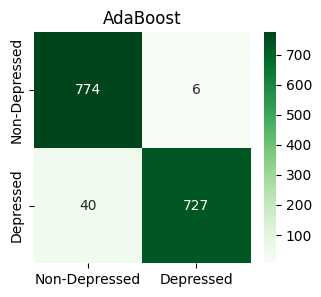

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm_ada = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3.5,3))
sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Greens", xticklabels=["Non-Depressed", "Depressed"], yticklabels=["Non-Depressed", "Depressed"])
plt.title("AdaBoost")
plt.show()

In [ ]:
!pip install xgboost lightgbm

[I 2026-02-07 07:53:06,880] A new study created in memory with name: no-name-d29db11d-552a-44c5-9e54-c6c6cf55b8c8


Starting Optuna...


[I 2026-02-07 07:53:25,661] Trial 0 finished with value: 0.9689524720615732 and parameters: {'n_estimators': 259, 'max_depth': 4, 'learning_rate': 0.21677588759155025}. Best is trial 0 with value: 0.9689524720615732.
[I 2026-02-07 07:53:36,975] Trial 1 finished with value: 0.97024412844006 and parameters: {'n_estimators': 131, 'max_depth': 6, 'learning_rate': 0.17019135563082677}. Best is trial 1 with value: 0.97024412844006.
[I 2026-02-07 07:53:48,467] Trial 2 finished with value: 0.9708878910939905 and parameters: {'n_estimators': 118, 'max_depth': 8, 'learning_rate': 0.18313008577613998}. Best is trial 2 with value: 0.9708878910939905.
[I 2026-02-07 07:54:06,689] Trial 3 finished with value: 0.97024412844006 and parameters: {'n_estimators': 251, 'max_depth': 5, 'learning_rate': 0.20051877053886985}. Best is trial 2 with value: 0.9708878910939905.
[I 2026-02-07 07:54:25,710] Trial 4 finished with value: 0.9708899849254321 and parameters: {'n_estimators': 255, 'max_depth': 5, 'learnin

Best Params: {'n_estimators': 157, 'max_depth': 7, 'learning_rate': 0.125240770522634}
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       780
           1       0.99      0.95      0.97       767

    accuracy                           0.97      1547
   macro avg       0.97      0.97      0.97      1547
weighted avg       0.97      0.97      0.97      1547

XGBoost training complete.


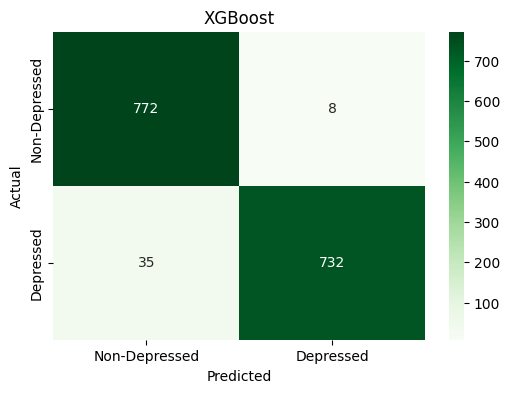

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
import joblib
import torch


SEED = 42

class XGBOnlyPipeline:
    def __init__(self, data_path):
        self.df = pd.read_pickle(data_path)
        self.cm_xgb = None
        self.best_model = None


    def prepare_data(self):
        y = self.df['is_depression']
        drop_cols = ['clean_text', 'is_depression'] + [c for c in self.df if c.startswith("sbert_")]
        X = self.df.drop(columns=drop_cols)

        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=SEED
        )

    def objective(self, trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3),
            "tree_method": "hist",
            "device": "cuda" if torch.cuda.is_available() else "cpu",
            "random_state": SEED
        }

        model = xgb.XGBClassifier(**params)
        model.fit(self.X_train, self.y_train)
        preds = model.predict(self.X_test)
        return f1_score(self.y_test, preds, average="macro")

    def run(self):
        print("Starting Optuna...")
        study = optuna.create_study(direction="maximize")
        study.optimize(self.objective, n_trials=30)

        print("Best Params:", study.best_params)

        self.best_model = xgb.XGBClassifier(
            **study.best_params,
            tree_method="hist",
            device="cuda" if torch.cuda.is_available() else "cpu",
            random_state=SEED
        )

        self.best_model.fit(self.X_train, self.y_train)

        preds = self.best_model.predict(self.X_test)

        print(classification_report(self.y_test, preds))


        self.cm_xgb = confusion_matrix(self.y_test, preds)


        os.makedirs("xgb_results", exist_ok=True)
        joblib.dump(self.best_model, "xgb_results/model.joblib")

        with open("xgb_results/best_params.json", "w") as f:
            json.dump(study.best_params, f, indent=4)


        np.save("xgb_results/confusion_matrix.npy", self.cm_xgb)

        print("XGBoost training complete.")

    def plot_confusion_matrix(self):
        if self.cm_xgb is None:
            print("Confusion matrix not found. Run model first.")
            return

        plt.figure(figsize=(6, 4))
        sns.heatmap(
            self.cm_xgb,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["Non-Depressed", "Depressed"],
            yticklabels=["Non-Depressed", "Depressed"]
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("XGBoost")
        plt.show()



xgb_pipeline = XGBOnlyPipeline("processed_data/full_features.pkl")
xgb_pipeline.prepare_data()
xgb_pipeline.run()
xgb_pipeline.plot_confusion_matrix()

In [ ]:
!pip install lightgbm

Columns available: Index(['clean_text', 'is_depression'], dtype='object')
[LightGBM] [Info] Number of positive: 3064, number of negative: 3120
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105801
[LightGBM] [Info] Number of data points in the train set: 6184, number of used features: 3784
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495472 -> initscore=-0.018112
[LightGBM] [Info] Start training from score -0.018112
Classification Report (LightGBM):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       780
           1       1.00      0.95      0.97       767

    accuracy                           0.97      1547
   macro avg       0.97      0.97      0.97      1547
weighted avg       0.97      0.97      0.97      1547



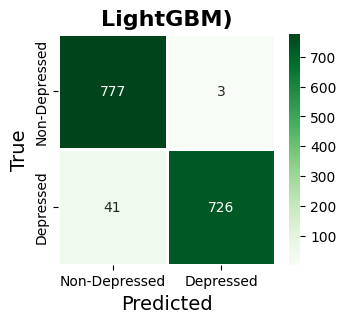

Accuracy (LightGBM): 0.9715578539107951


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix


from lightgbm import LGBMClassifier

path = '/content/Integrating AI-DataSet_Youth_Wellness.xlsx'
df = pd.read_excel(path, sheet_name="Sheet3")


df_cleaned = df.copy()

print("Columns available:", df_cleaned.columns)
df_cleaned.head()

X_text_clean = df_cleaned['clean_text'].astype(str).values
y_clean = df_cleaned['is_depression'].values

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_text_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

vectorizer_clean = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_vec_clean = vectorizer_clean.fit_transform(X_train_clean)
X_test_vec_clean = vectorizer_clean.transform(X_test_clean)

model_lgbm = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

model_lgbm.fit(X_train_vec_clean, y_train_clean)

y_pred_lgbm = model_lgbm.predict(X_test_vec_clean)

from sklearn.metrics import classification_report

print("Classification Report (LightGBM):")
print(classification_report(y_test_clean, y_pred_lgbm))

cm_lgbm = confusion_matrix(y_test_clean, y_pred_lgbm)

plt.figure(figsize=(3.5, 3))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='white',
    xticklabels=["Non-Depressed", "Depressed"],
    yticklabels=["Non-Depressed", "Depressed"]
)

plt.title("LightGBM)", fontsize=16, weight="bold")
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.show()

print("Accuracy (LightGBM):", accuracy_score(y_test_clean, y_pred_lgbm))

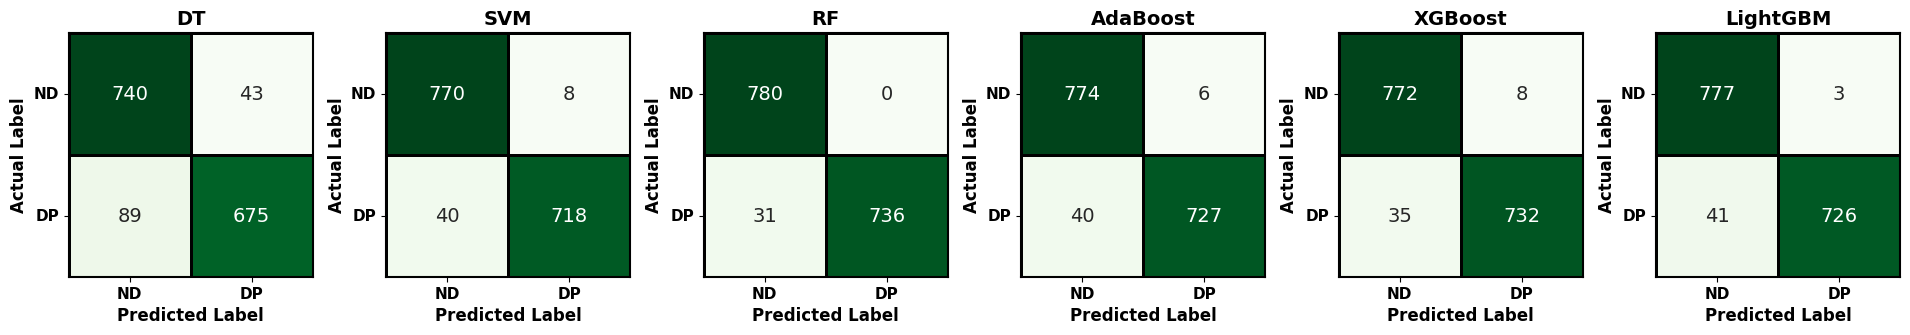

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_confusion_matrices(cm_dict):
    n = len(cm_dict)
    cols = n
    rows = 1

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for idx, (name, cm) in enumerate(cm_dict.items(), 1):
        plt.subplot(rows, cols, idx)
        ax = sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            cbar=False,
            annot_kws={"size": 14},
            xticklabels=["ND", "DP"],
            yticklabels=["ND", "DP"],
            linewidths=1,
            linecolor="black",
            square=True
        )

        plt.title(name, fontsize=14, fontweight="bold")
        plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
        plt.ylabel("Actual Label", fontsize=12, fontweight="bold")
        plt.xticks(fontsize=11, fontweight="bold")
        plt.yticks(fontsize=11, rotation=0, fontweight="bold")

        for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)
                spine.set_color("black")

    plt.tight_layout()
    plt.savefig("all_confusion_matrices.png") # Save the figure
    plt.show()

confusion_matrices = {
    "DT": cm_gini,
    "SVM": cm_svm,
    "RF": cm_rf,
    "AdaBoost": cm_ada,
    "XGBoost": xgb_pipeline.cm_xgb,
    "LightGBM": cm_lgbm
}

plot_all_confusion_matrices(confusion_matrices)